In [9]:
import sys
sys.path.insert(0, '../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

In [ ]:
def plot_scatter_panel(ax, df, color, title, groupby_subject=False, annotate=False, lim = [-0.02, 0.35]):

    if groupby_subject:
        agg       = df.groupby('subject')[['r_att', 'r_ign']].mean()
        r_att     = agg['r_att'].values
        r_ign     = agg['r_ign'].values
        labels    = [s.replace('sub-', '') for s in agg.index]
    else:
        r_att  = df['r_att'].values
        r_ign  = df['r_ign'].values
        labels = df['subject'].str.replace('sub-', '').values

    correct = r_att > r_ign
    acc     = correct.mean()

    ax.scatter(r_att[correct],  r_ign[correct],
               color=color, edgecolors='white', linewidths=0.5,
               s=65, zorder=3, marker='o', label=f'Correct ({acc:.0%})')
    ax.scatter(r_att[~correct], r_ign[~correct],
               color=color, edgecolors='red', linewidths=0.8,
               s=65, zorder=3, marker='X', label=f'Incorrect ({1-acc:.0%})')

    if annotate:
        for s, x, y in zip(labels, r_att, r_ign):
            ax.annotate(s, (x, y),
                        textcoords='offset points', xytext=(5, 3),
                        fontsize=6.5, color=color, alpha=0.85)

    all_r = np.concatenate([r_att, r_ign])
    ax.plot(lim, lim, 'k--', linewidth=0.9, alpha=0.5, zorder=2)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$r_{att}$', fontsize=9)
    ax.set_ylabel(r'$r_{ign}$', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7.5, loc='upper left', framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

In [11]:
results_nh = pd.read_csv('results_nh.csv')
results_hi = pd.read_csv('results_hi.csv')

results_nh_cat = pd.read_csv('results_nh_cat.csv')
results_hi_cat = pd.read_csv('results_hi_cat.csv')

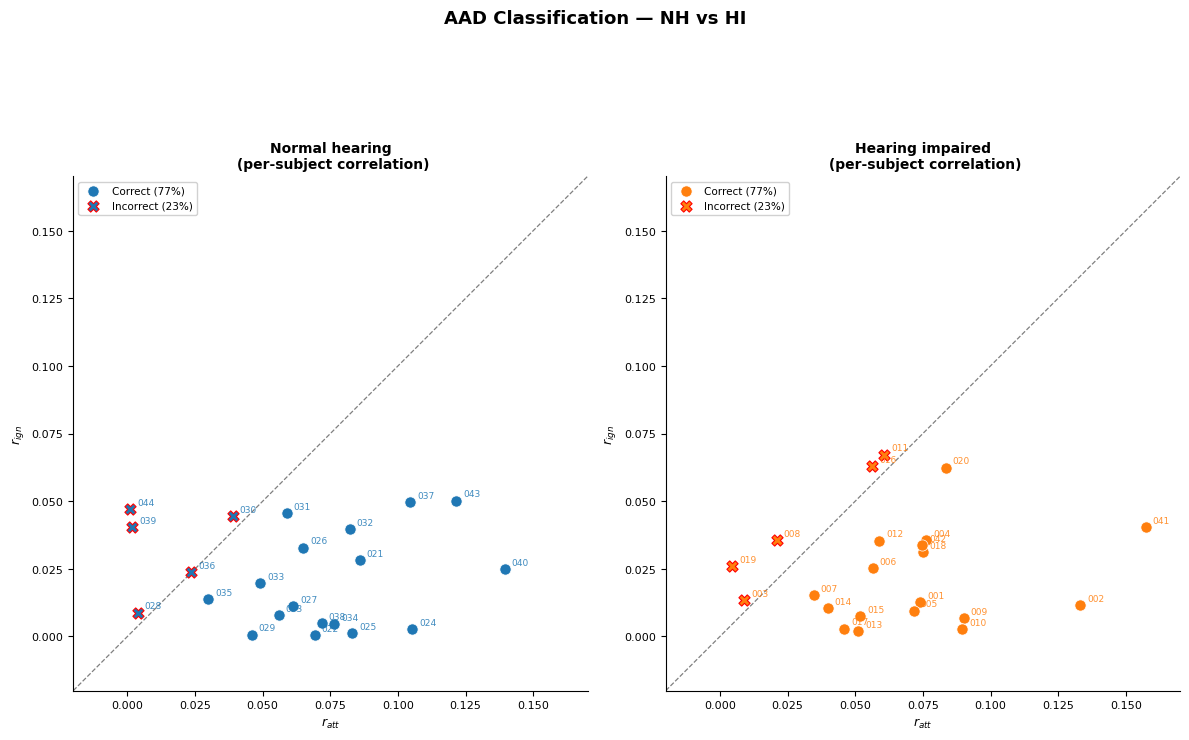

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8.5))
ax_nh = axes[0]
ax_hi = axes[1]
plot_scatter_panel(
    ax_nh, results_nh_cat,
    color='tab:blue',
    title='Normal hearing\n (per-subject correlation)',
    groupby_subject=False,
    annotate=True,
    lim=[-0.02,0.17]
)
plot_scatter_panel(
    ax_hi, results_hi_cat,
    color='tab:orange',
    title='Hearing impaired\n (per-subject correlation)',
    groupby_subject=False,
    annotate=True,
    lim=[-0.02,0.17]
)
fig.suptitle('AAD Classification — NH vs HI', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / 'aad_subject_scatter_nh_hi.png', dpi=170, bbox_inches='tight')
plt.show()

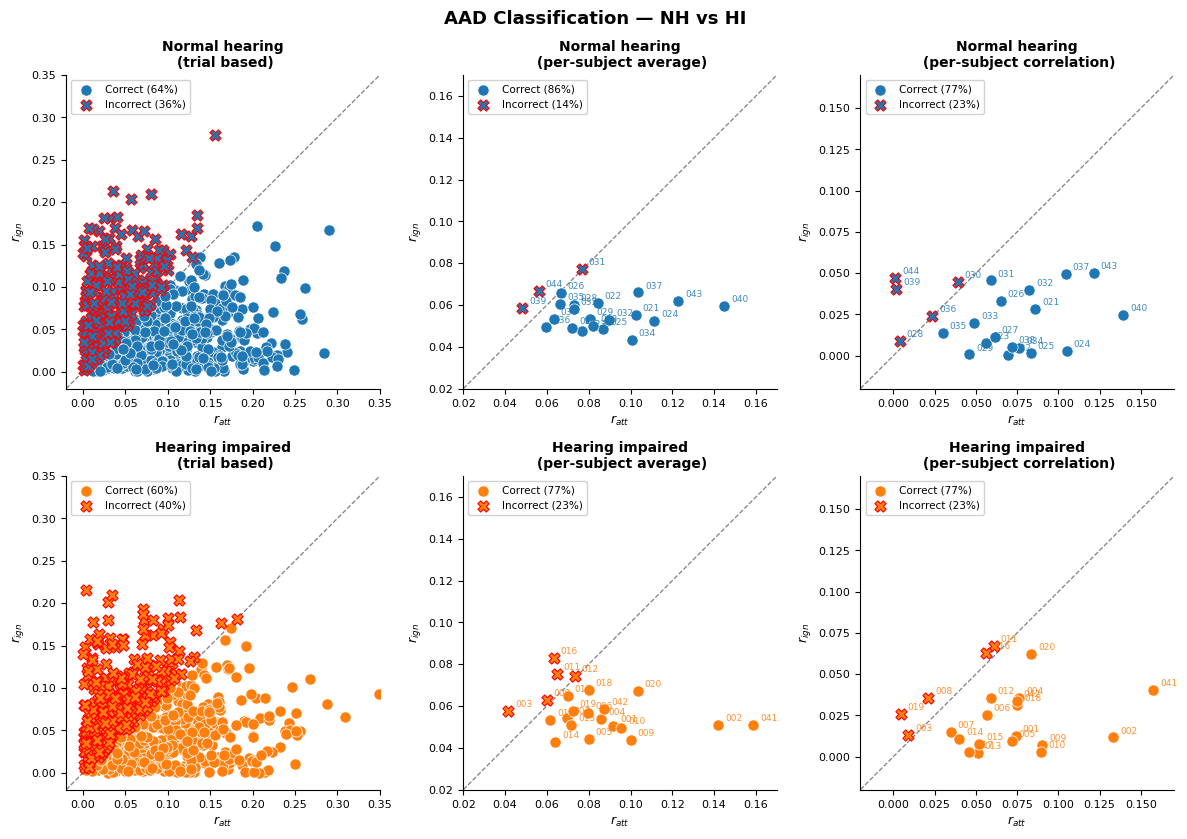

In [13]:
# ALL AAD APPROACHES --------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(12, 8.5))
ax_nh1, ax_nh2, ax_nh3 = axes[0]
ax_hi1, ax_hi2, ax_hi3 = axes[1]

plot_scatter_panel(
    ax_nh1, results_nh,
    color='tab:blue',
    title='Normal hearing\n (trial based)',
    groupby_subject=False
)
plot_scatter_panel(
    ax_nh2, results_nh,
    color='tab:blue',
    title='Normal hearing\n (per-subject average)',
    groupby_subject=True,
    annotate=True,
    lim=[0.02,0.17]
)
plot_scatter_panel(
    ax_nh3, results_nh_cat,
    color='tab:blue',
    title='Normal hearing\n (per-subject correlation)',
    groupby_subject=False,
    annotate=True,
    lim=[-0.02,0.17]
)


plot_scatter_panel(
    ax_hi1, results_hi,
    color='tab:orange',
    title='Hearing impaired\n (trial based)',
    groupby_subject=False
)
plot_scatter_panel(
    ax_hi2, results_hi,
    color='tab:orange',
    title='Hearing impaired\n (per-subject average)',
    groupby_subject=True,
    annotate=True,
    lim=[0.02,0.17]
)
plot_scatter_panel(
    ax_hi3, results_hi_cat,
    color='tab:orange',
    title='Hearing impaired\n (per-subject correlation)',
    groupby_subject=False,
    annotate=True,
    lim=[-0.02,0.17]
)


fig.suptitle('AAD Classification — NH vs HI', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / 'aad_scatter_nh_hi.png', dpi=170, bbox_inches='tight')
plt.show()

In [14]:
 

plot_scatter_panel(
    ax_nh3, results_nh_cat,
    color='tab:blue',
    title='Normal hearing\n (per-subject correlation)',
    groupby_subject=False,
    annotate=True,
    lim=[-0.02,0.17]
)

In [15]:
def test_against_chance(results_df, chance=0.5, level='subject'):
    """
    Test whether decoding accuracy is significantly above chance.
    
    level='subject' : one-sample t-test on per-subject accuracies (recommended)
    level='trial'   : binomial test on all trials pooled
    """
    if level == 'subject':
        subj_acc = results_df.groupby('subject')['correct'].mean()
        t, p = scipy.stats.ttest_1samp(subj_acc, popmean=chance, alternative='greater')
        n = len(subj_acc)
        mean_acc = subj_acc.mean()
        sem = subj_acc.sem()
        print(f"One-sample t-test (n={n} subjects)")
        print(f"  Mean accuracy: {mean_acc:.1%} ± {sem:.1%} SEM")
        print(f"  t({n-1}) = {t:.3f}, p = {p:.4f} (one-tailed)")
        return {'test': 't-test', 'mean': mean_acc, 'sem': sem,
                't': t, 'df': n-1, 'p': p, 'n': n}

    elif level == 'trial':
        n_correct = results_df['correct'].sum()
        n_total   = len(results_df)
        p = scipy.stats.binomtest(n_correct, n_total, p=chance, alternative='greater').pvalue
        mean_acc = n_correct / n_total
        print(f"Binomial test (n={n_total} trials)")
        print(f"  Accuracy: {n_correct}/{n_total} = {mean_acc:.1%}")
        print(f"  p = {p:.4f} (one-tailed)")
        return {'test': 'binomial', 'mean': mean_acc,
                'n_correct': n_correct, 'n': n_total, 'p': p}

In [16]:
# Recommended: t-test across subject accuracies
stats_hi = test_against_chance(results_hi, level='subject')
stats_nh = test_against_chance(results_nh, level='subject')

# Optional: pooled binomial
test_against_chance(results_hi, level='trial')
print("done")

One-sample t-test (n=22 subjects)
  Mean accuracy: 59.8% ± 3.0% SEM
  t(21) = 3.279, p = 0.0018 (one-tailed)
One-sample t-test (n=22 subjects)
  Mean accuracy: 64.3% ± 2.5% SEM
  t(21) = 5.741, p = 0.0000 (one-tailed)
Binomial test (n=704 trials)
  Accuracy: 421/704 = 59.8%
  p = 0.0000 (one-tailed)
done
